<a href="https://colab.research.google.com/github/Nikhil5566/EDA-Repo/blob/main/Data_Science_Student_Marks_Dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()
import warnings
warnings.filterwarnings('ignore')

In [ ]:
# Installing Kaggle API
!pip install -q kaggle

# Uploading kaggle.json
from google.colab import files
files.upload()

# Moving kaggle.json to ~/.kaggle/
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# Downloading the dataset using Kaggle API
!kaggle datasets download -d ayeshaimran123/data-science-student-marks

# Unziping the downloaded file
!unzip data-science-student-marks.zip

Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/ayeshaimran123/data-science-student-marks
License(s): ODC Public Domain Dedication and Licence (PDDL)
  0% 0.00/5.08k [00:00<?, ?B/s]
100% 5.08k/5.08k [00:00<00:00, 21.8MB/s]
Archive:  data-science-student-marks.zip
  inflating: data_science_student_marks.csv  


In [ ]:
df = pd.read_csv('data_science_student_marks.csv')
df.head(11)

,student_id,location,age,sql_marks,excel_marks,python_marks,power_bi_marks,english_marks
0,4,Sydney,24,95,99,87,82,75
1,5,Tokyo,24,99,95,89,86,82
2,6,Berlin,22,72,70,99,79,77
3,7,London,23,97,90,74,72,85
4,8,Tokyo,22,91,71,79,80,75
5,9,Toronto,20,93,88,75,93,72
6,10,Tokyo,18,77,87,100,98,93
7,11,Toronto,21,78,90,88,79,72
8,12,Melbourne,24,80,95,87,90,94
9,13,London,19,97,80,96,97,86


In [ ]:
df.tail(11)

,student_id,location,age,sql_marks,excel_marks,python_marks,power_bi_marks,english_marks
486,490,Tokyo,18,87,100,95,89,85
487,491,Melbourne,25,75,77,82,99,83
488,492,London,23,85,73,78,81,96
489,493,Los Angeles,24,94,74,80,92,95
490,494,Melbourne,25,84,96,72,93,86
491,495,New York,24,83,78,82,84,84
492,496,New York,23,71,92,98,78,88
493,497,Los Angeles,20,90,100,90,78,73
494,498,Paris,22,78,80,78,71,70
495,499,Los Angeles,21,96,93,78,78,82


In [ ]:
df.shape

(497, 8)

In [ ]:
df.columns

Index(['student_id', 'location', 'age', 'sql_marks', 'excel_marks',
       'python_marks', 'power_bi_marks', 'english_marks'],
      dtype='object')

In [ ]:
df.dtypes

,0
student_id,int64
location,object
age,int64
sql_marks,int64
excel_marks,int64
python_marks,int64
power_bi_marks,int64
english_marks,int64


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 497 entries, 0 to 496
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   student_id      497 non-null    int64 
 1   location        497 non-null    object
 2   age             497 non-null    int64 
 3   sql_marks       497 non-null    int64 
 4   excel_marks     497 non-null    int64 
 5   python_marks    497 non-null    int64 
 6   power_bi_marks  497 non-null    int64 
 7   english_marks   497 non-null    int64 
dtypes: int64(7), object(1)
memory usage: 31.2+ KB


In [ ]:
df.describe(include = 'all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
student_id,497.0,NaN,NaN,NaN,252.0,143.615807,4.0,128.0,252.0,376.0,500.0
location,497,9,Tokyo,60,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age,497.0,NaN,NaN,NaN,21.380282,2.205714,18.0,20.0,21.0,23.0,25.0
sql_marks,497.0,NaN,NaN,NaN,84.661972,8.745415,70.0,78.0,85.0,92.0,100.0
excel_marks,497.0,NaN,NaN,NaN,85.384306,8.782497,70.0,78.0,86.0,93.0,100.0
python_marks,497.0,NaN,NaN,NaN,85.38833,8.878668,70.0,77.0,86.0,94.0,100.0
power_bi_marks,497.0,NaN,NaN,NaN,84.545272,8.903066,70.0,77.0,84.0,92.0,100.0
english_marks,497.0,NaN,NaN,NaN,84.82495,9.060479,70.0,77.0,85.0,93.0,100.0


In [17]:
df.isnull().sum()

,0
student_id,0
location,0
age,0
sql_marks,0
excel_marks,0
python_marks,0
power_bi_marks,0
english_marks,0


In [18]:
df.duplicated().sum()

np.int64(0)

# Handling Outliers

In [19]:
Q1 = df['excel_marks'].quantile(0.25)
Q3 = df['excel_marks'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df_Outliers = df[(df['excel_marks'] >= lower_bound) | (df['excel_marks'] <= upper_bound)].copy()

print(f'Original Shape: {len(df)}')
print(f'Shape after outlier handling: {len(df_Outliers)}')

Original Shape: 497
Shape after outlier handling: 497


# Univariate Analysis

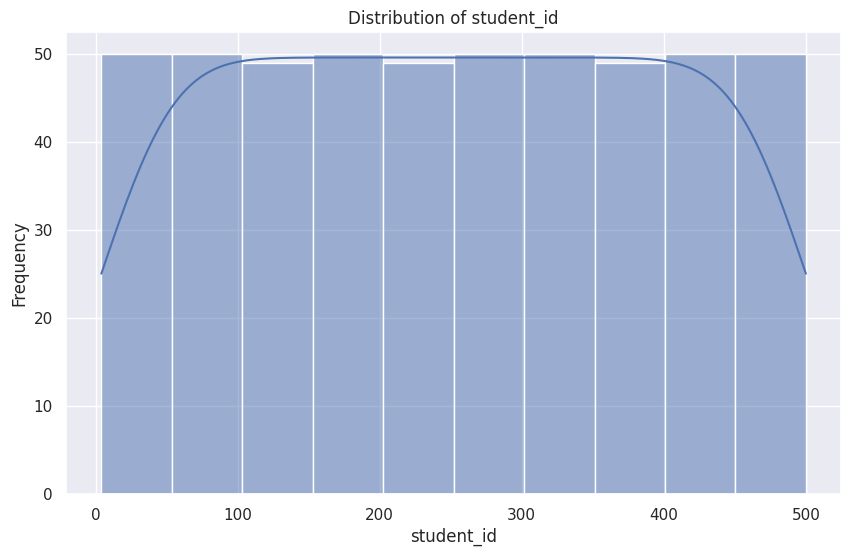

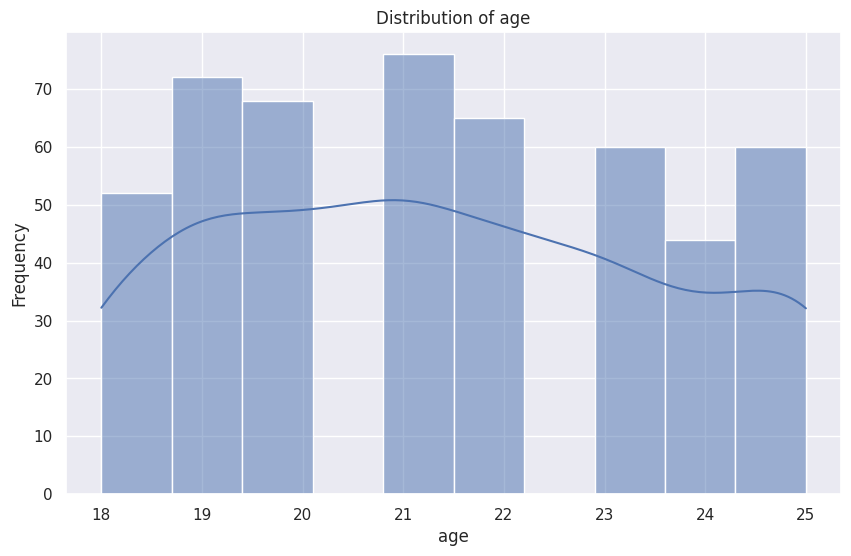

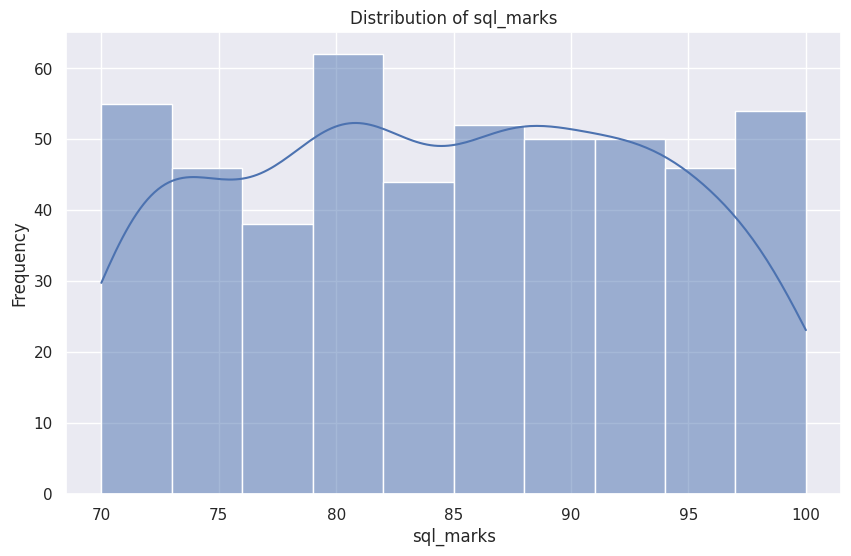

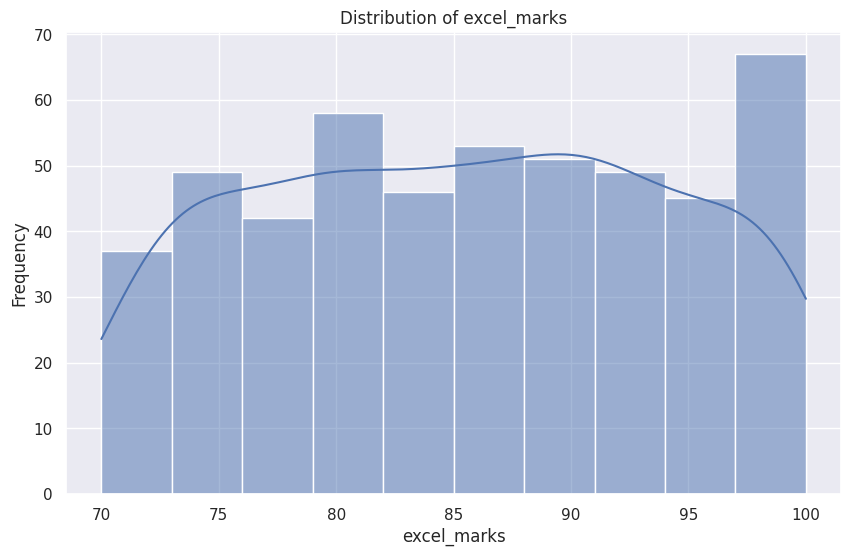

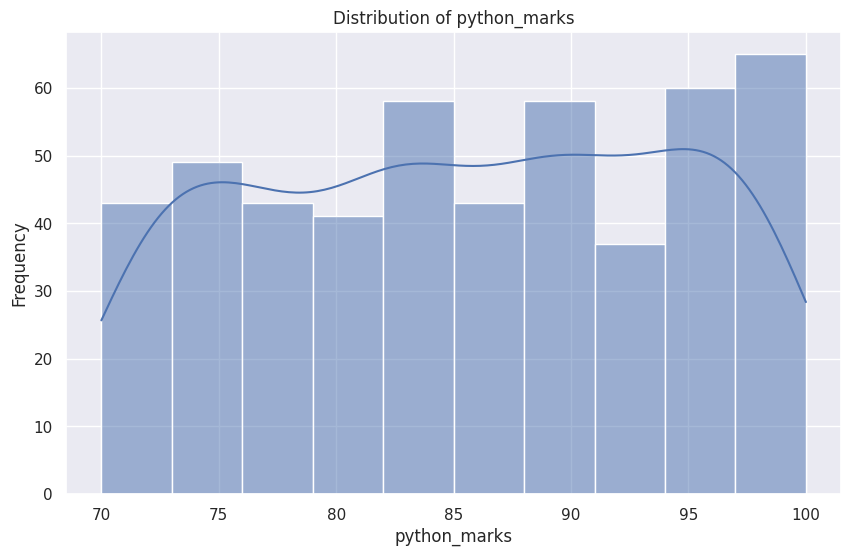

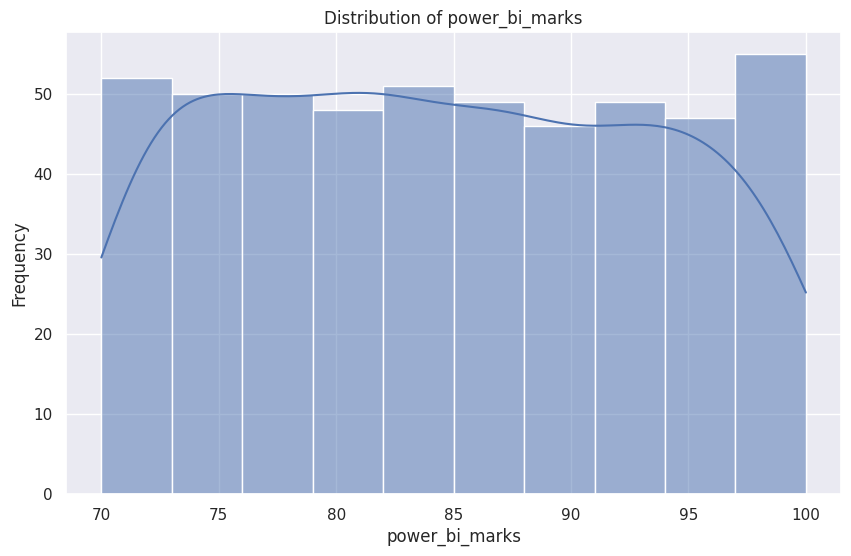

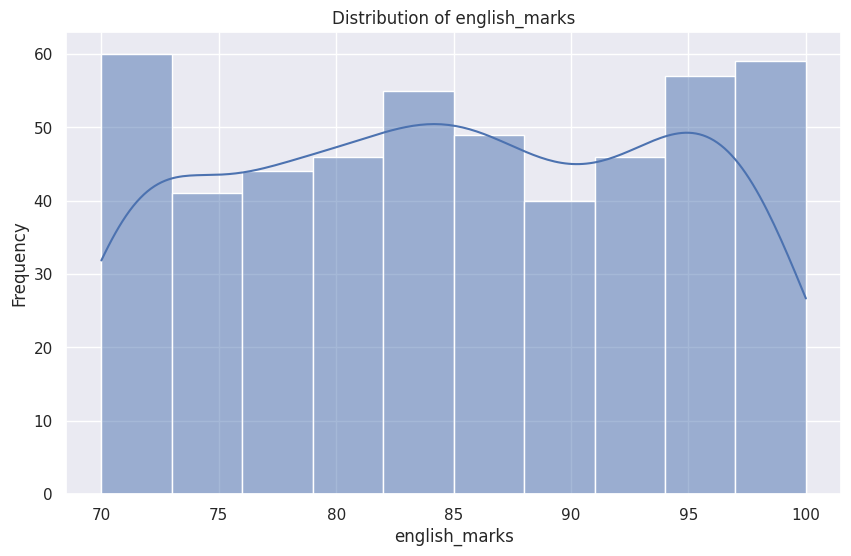

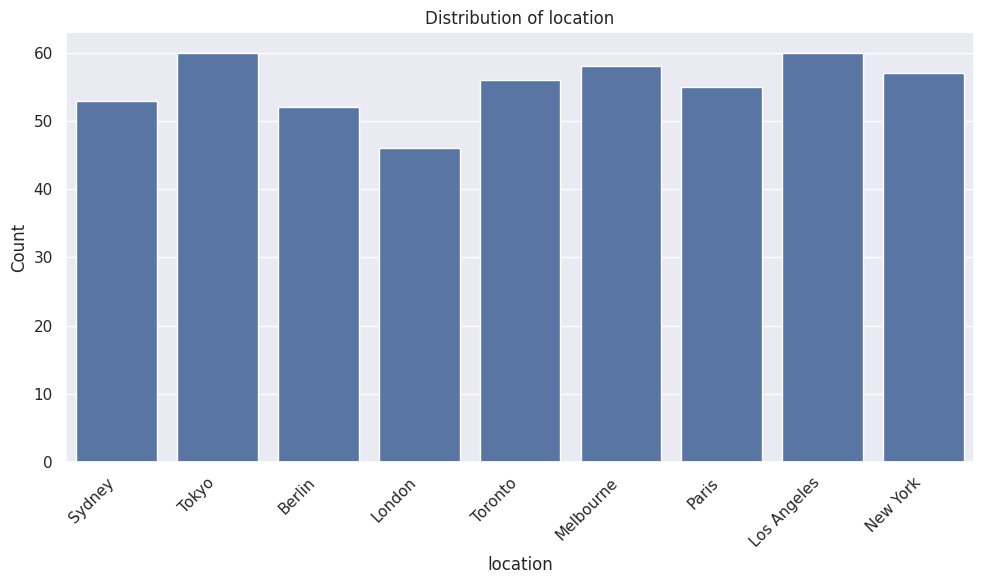

Value counts for location:
location
Tokyo          60
Los Angeles    60
Melbourne      58
New York       57
Toronto        56
Paris          55
Sydney         53
Berlin         52
London         46
Name: count, dtype: int64



In [ ]:
# Getting a list of numerical columns
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

# Iterating through numerical columns and create histograms
for col in numerical_cols:
    plt.figure(figsize=(10, 6))
    sns.histplot(data=df, x=col, kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()

# Getting a list of categorical columns
categorical_cols = df.select_dtypes(include='object').columns.tolist()

# Iterate through categorical columns and create countplots
for col in categorical_cols:
    plt.figure(figsize=(10, 6))
    sns.countplot(data=df, x=col)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

# We can also use value_counts for a quick look at categorical data distribution
for col in categorical_cols:
    print(f"Value counts for {col}:\n{df[col].value_counts()}\n")

# Bivariate Analysis

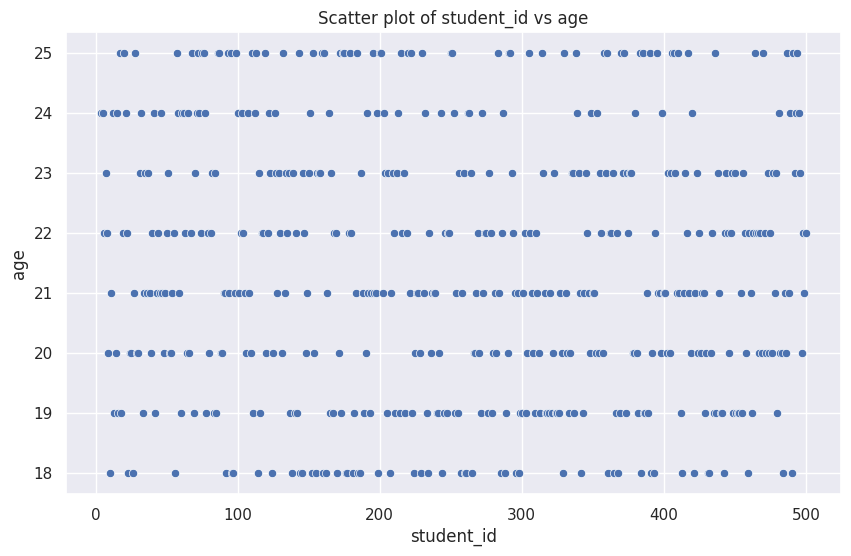

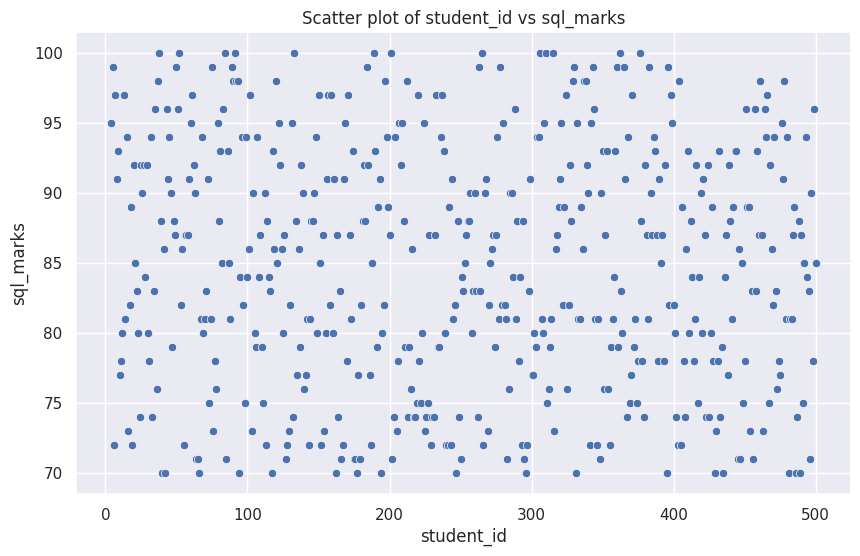

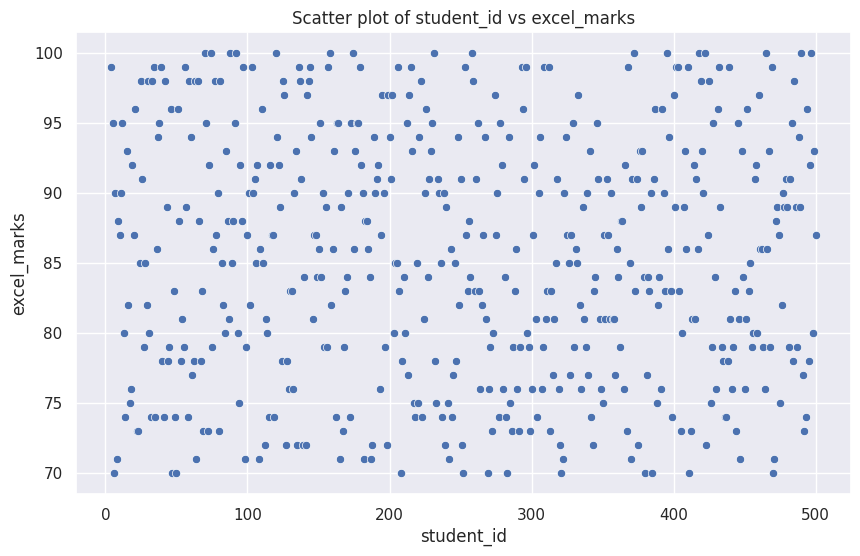

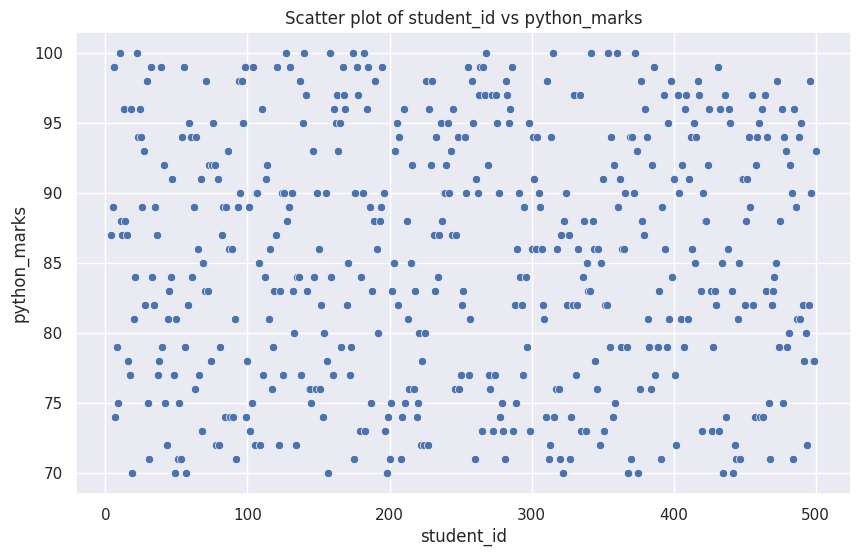

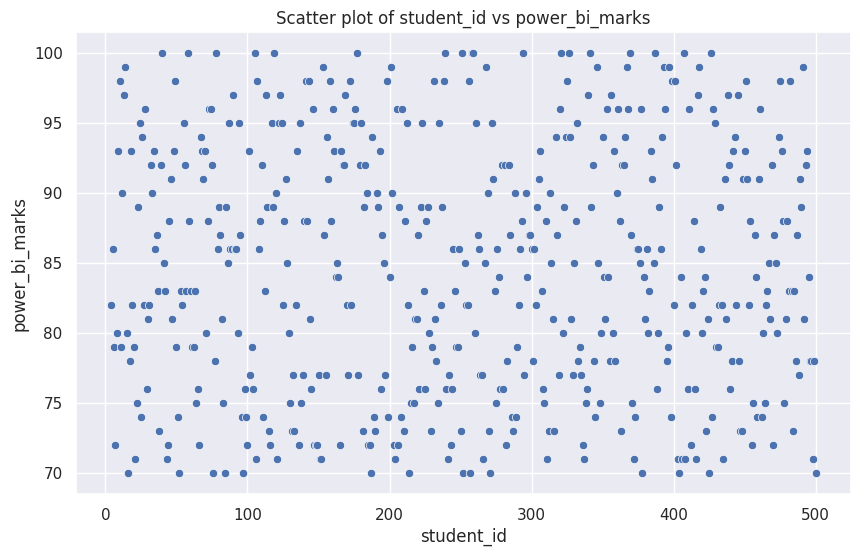

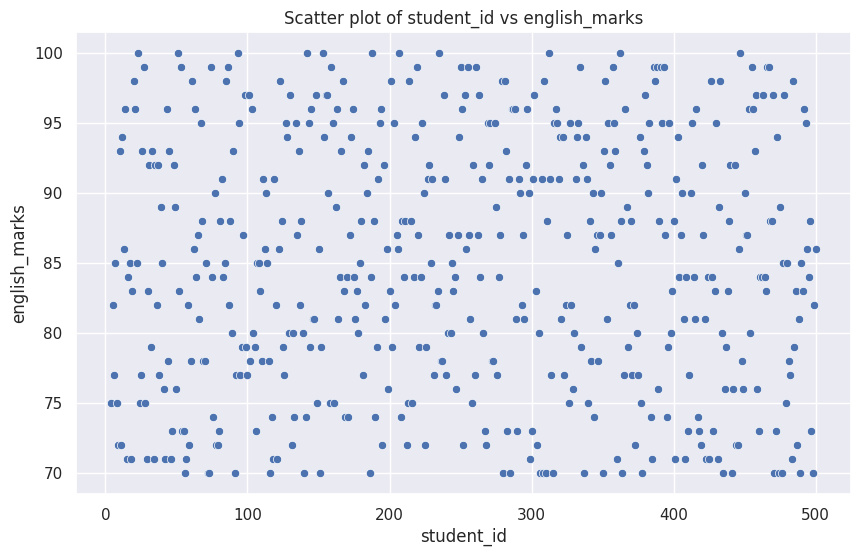

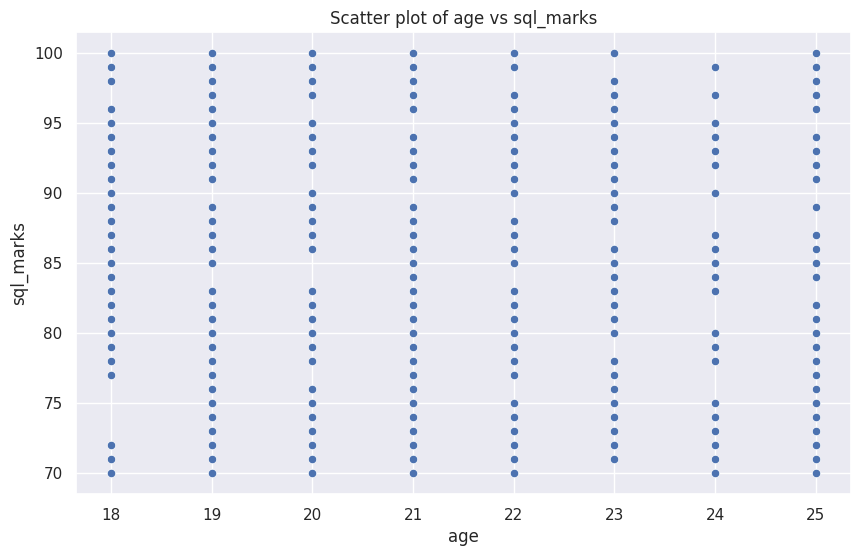

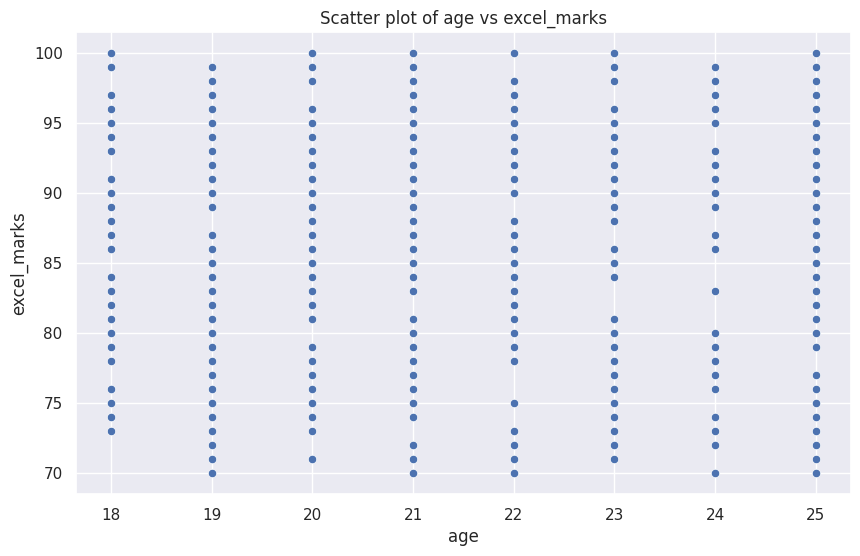

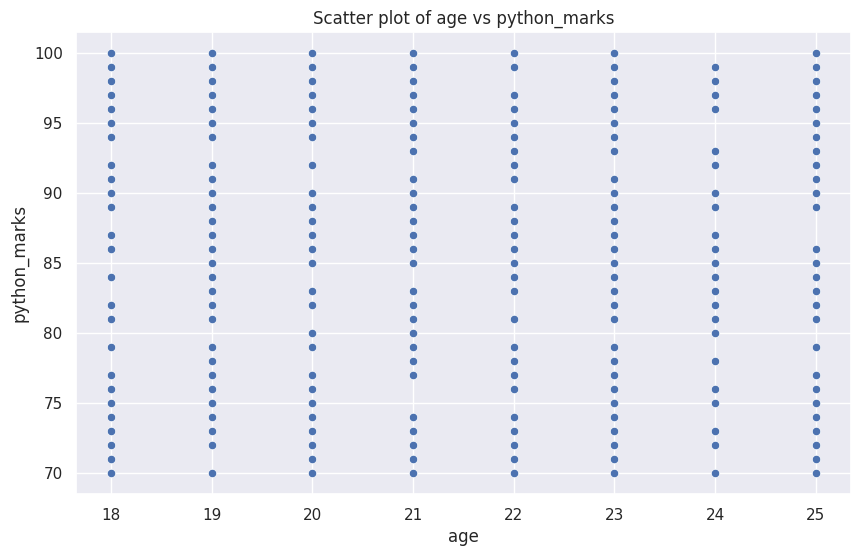

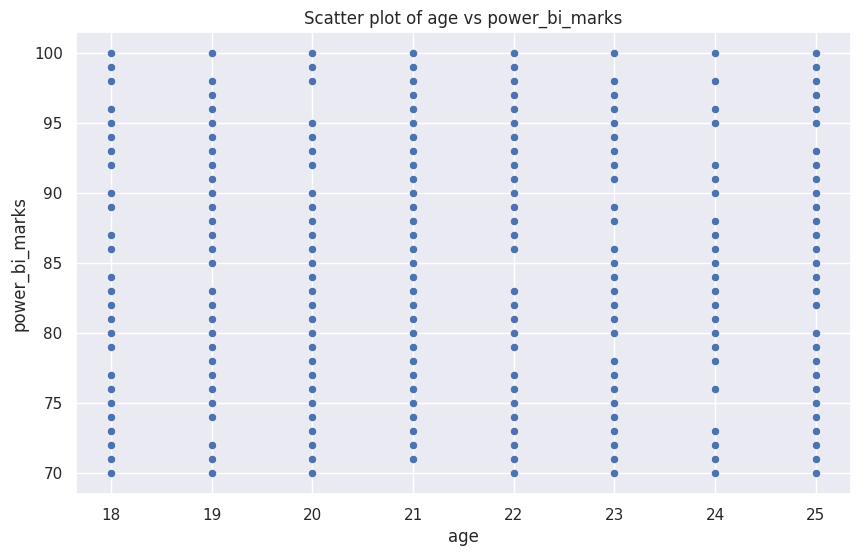

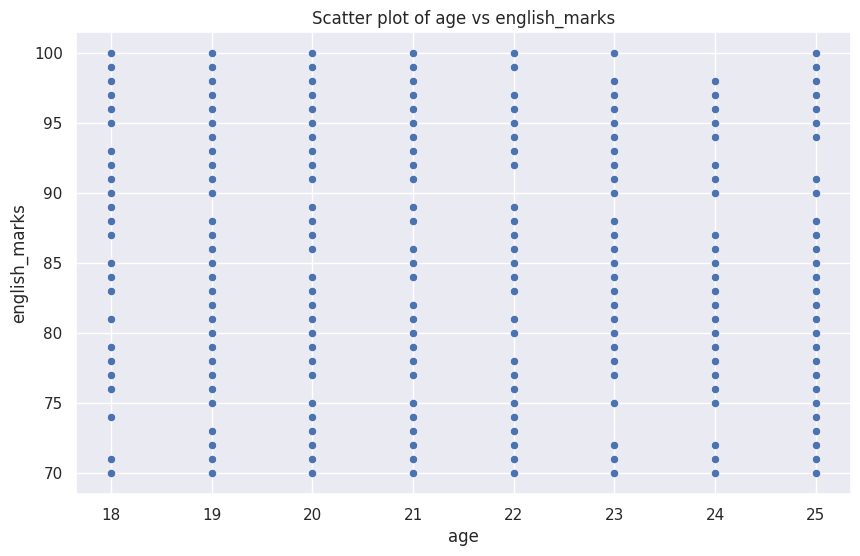

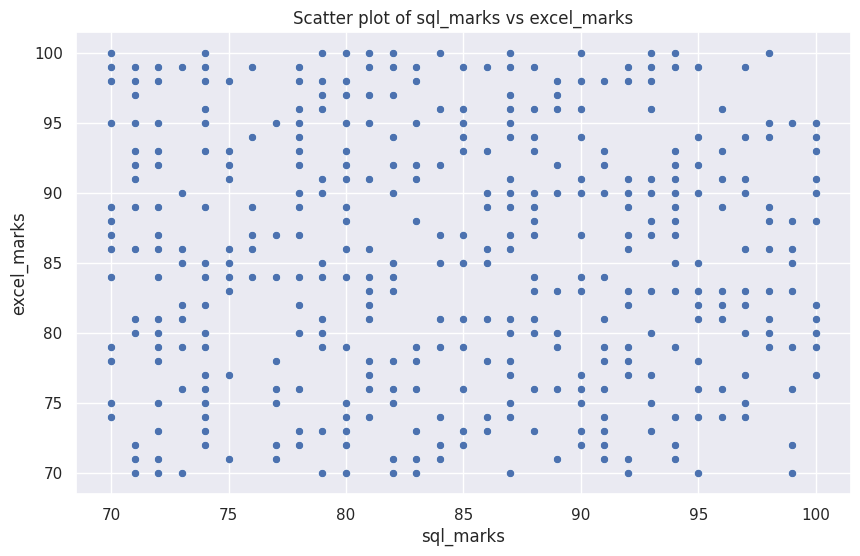

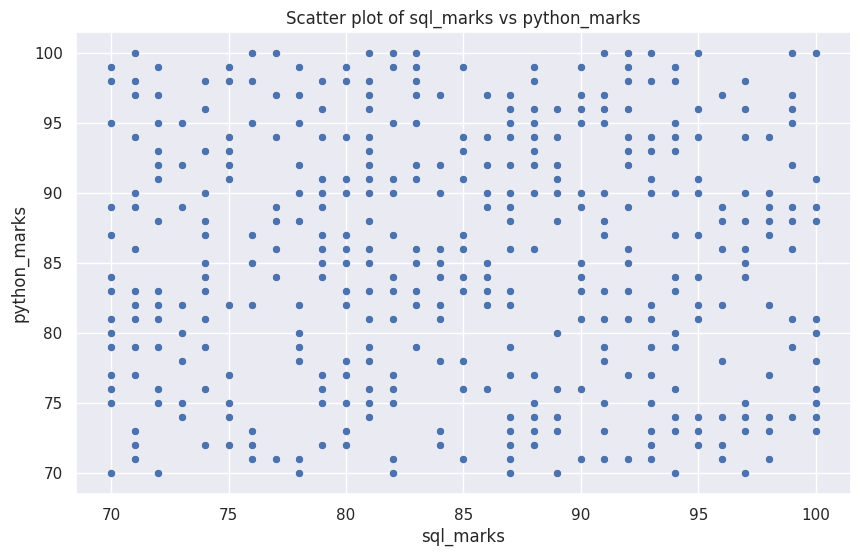

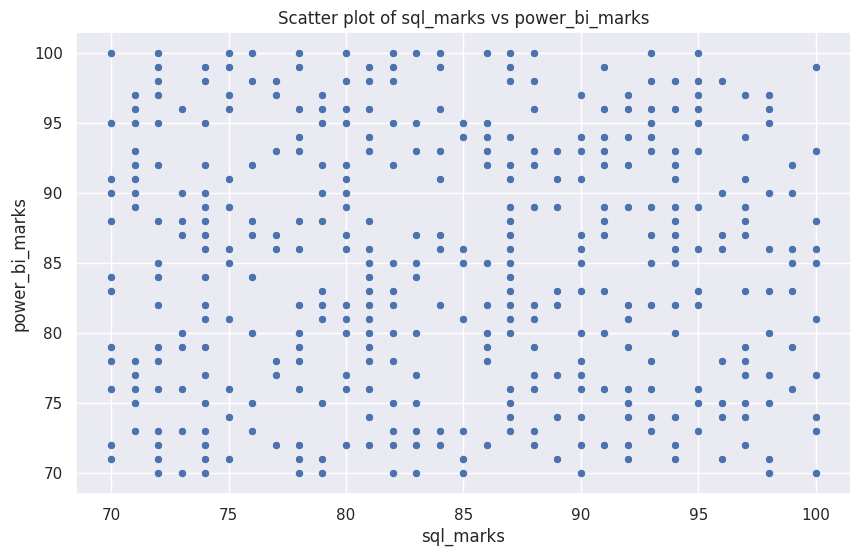

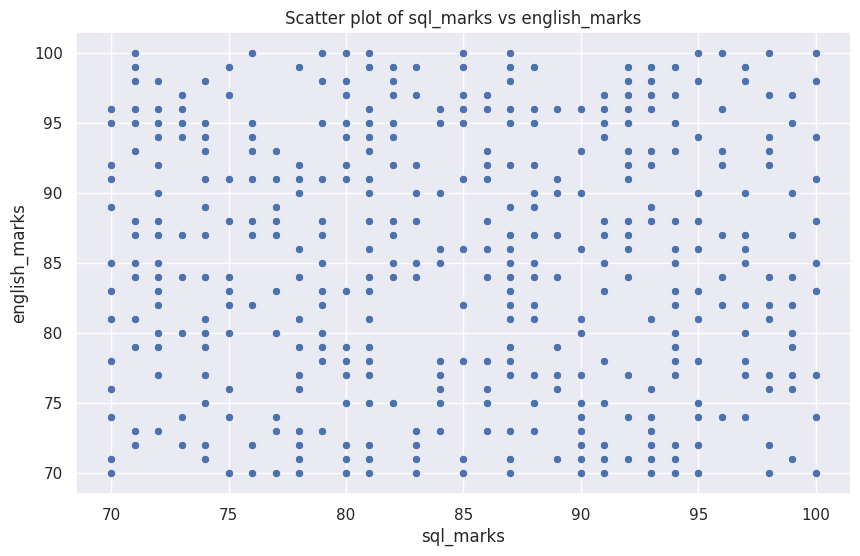

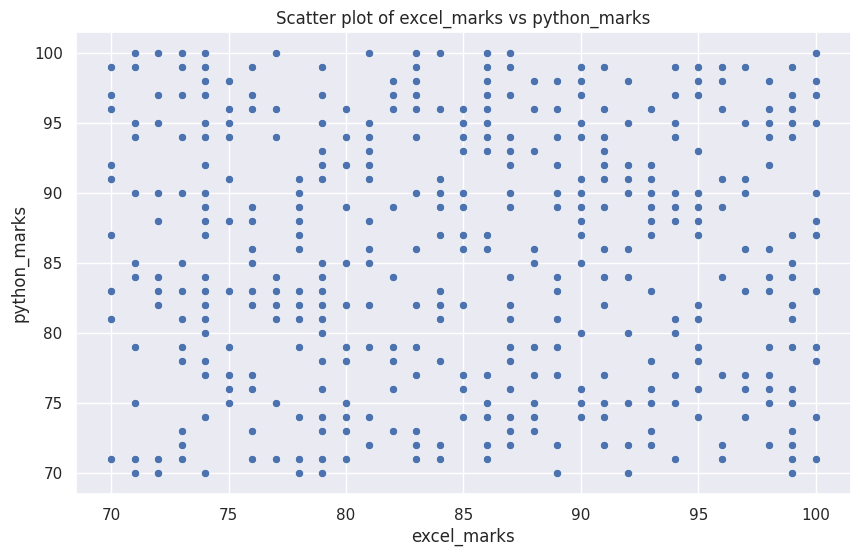

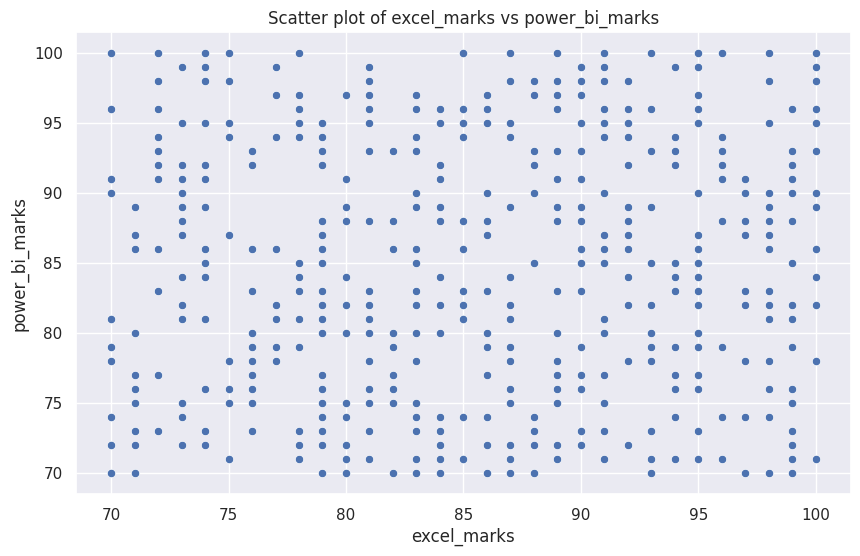

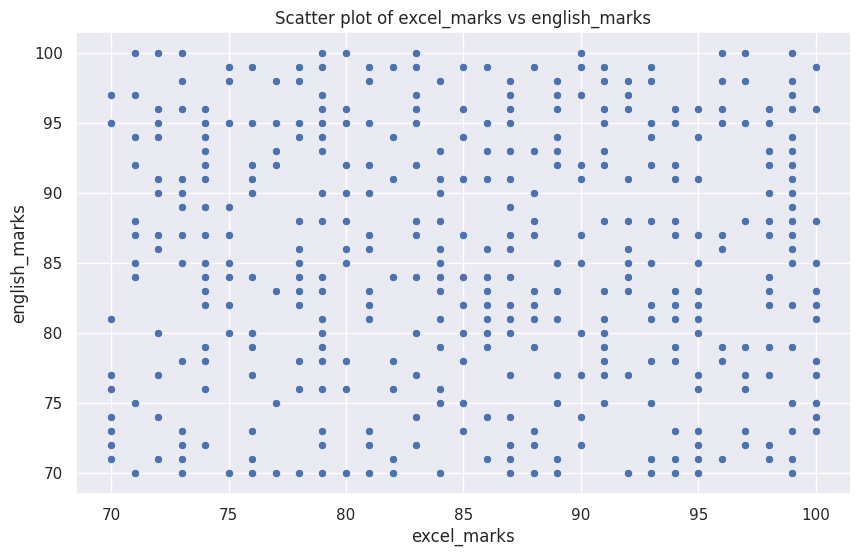

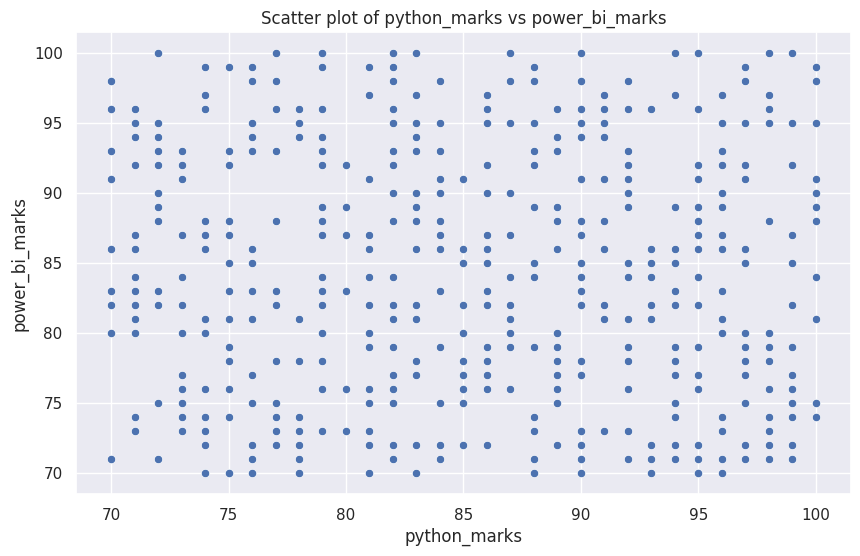

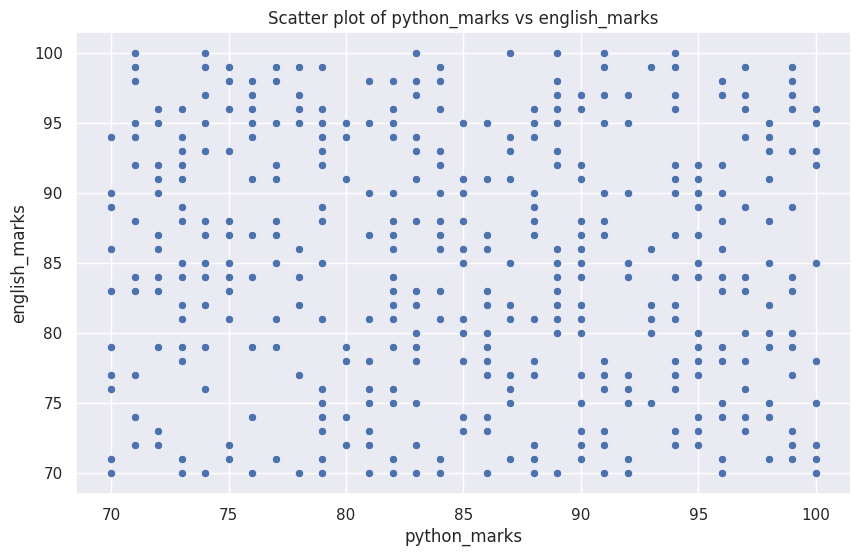

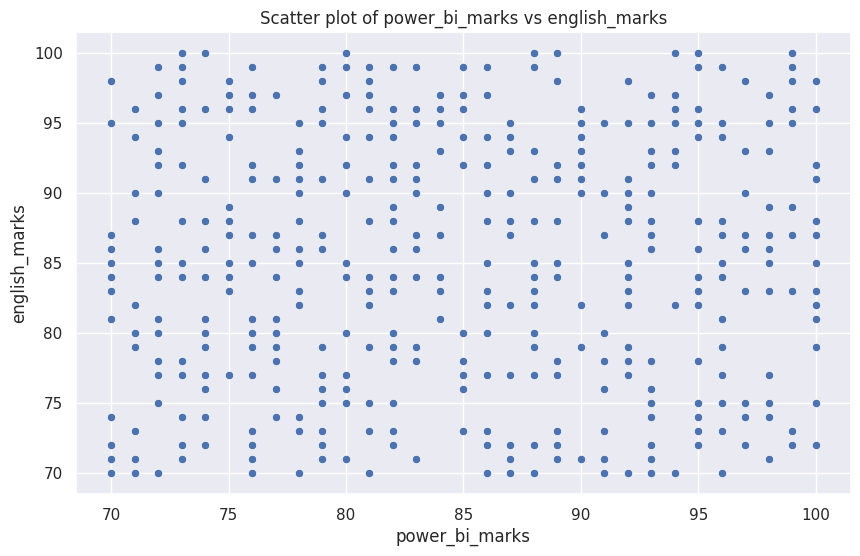

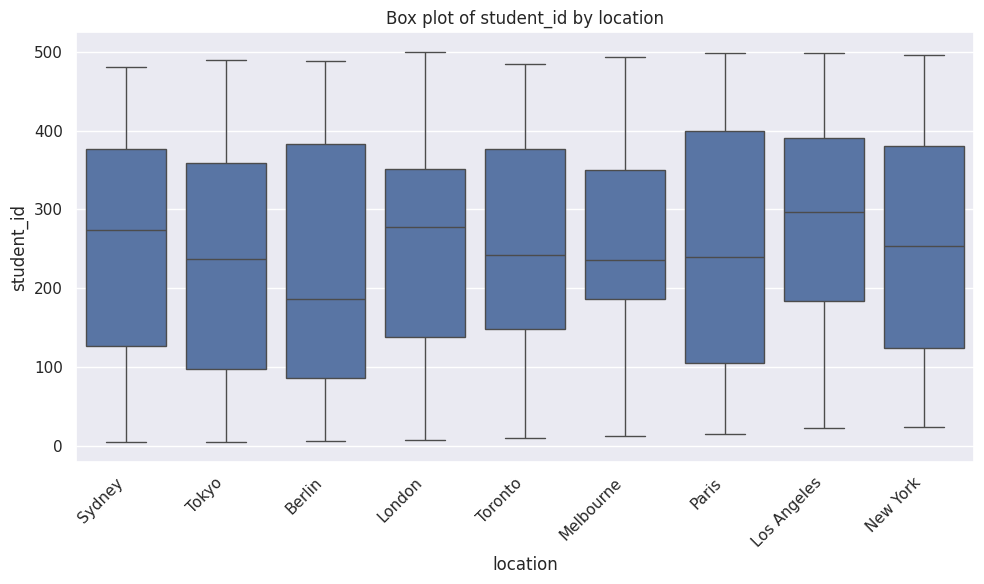

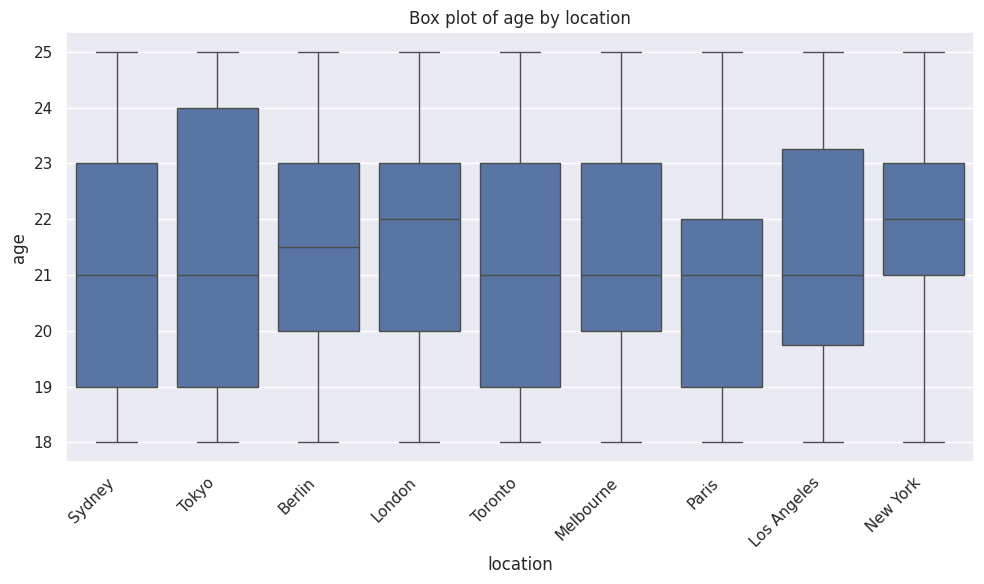

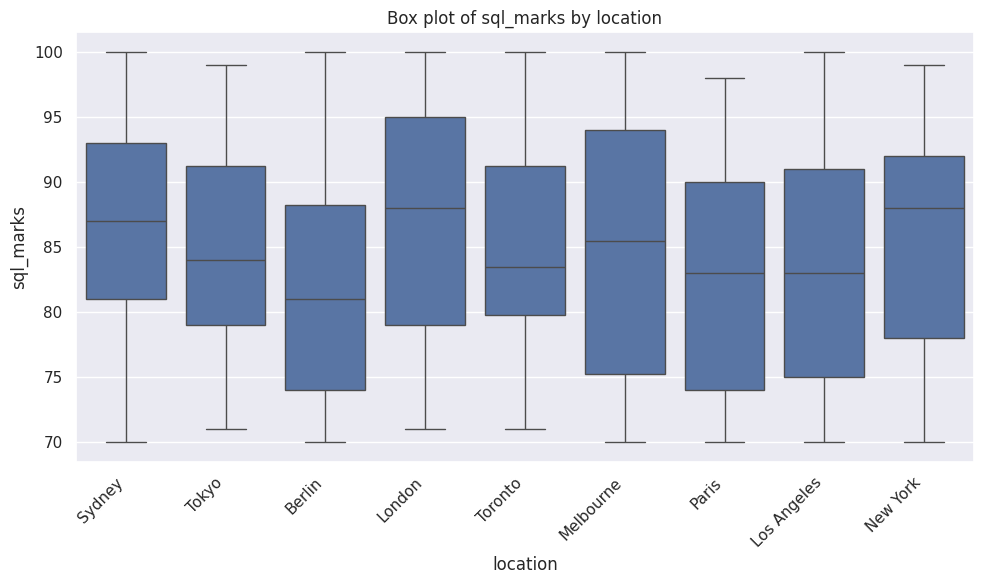

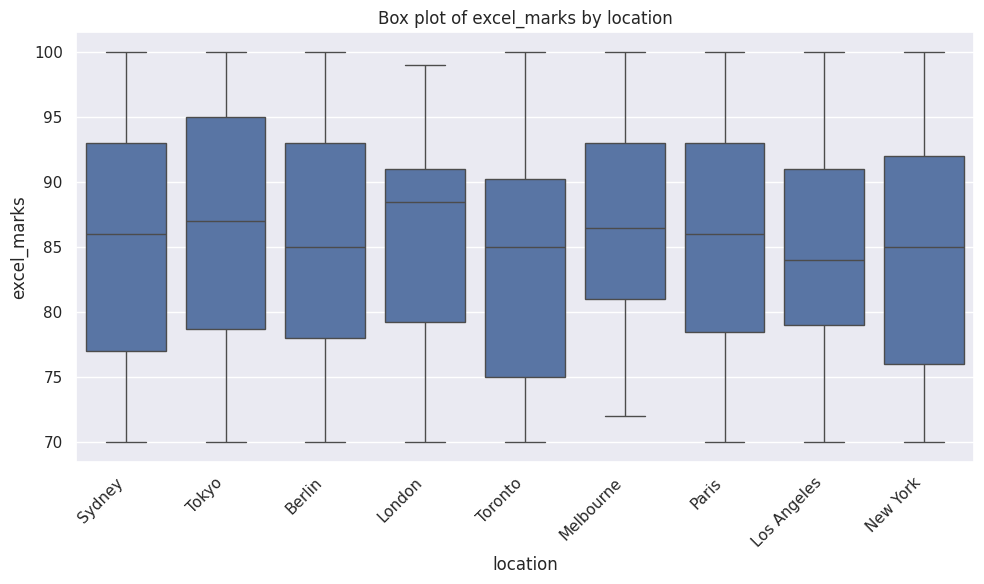

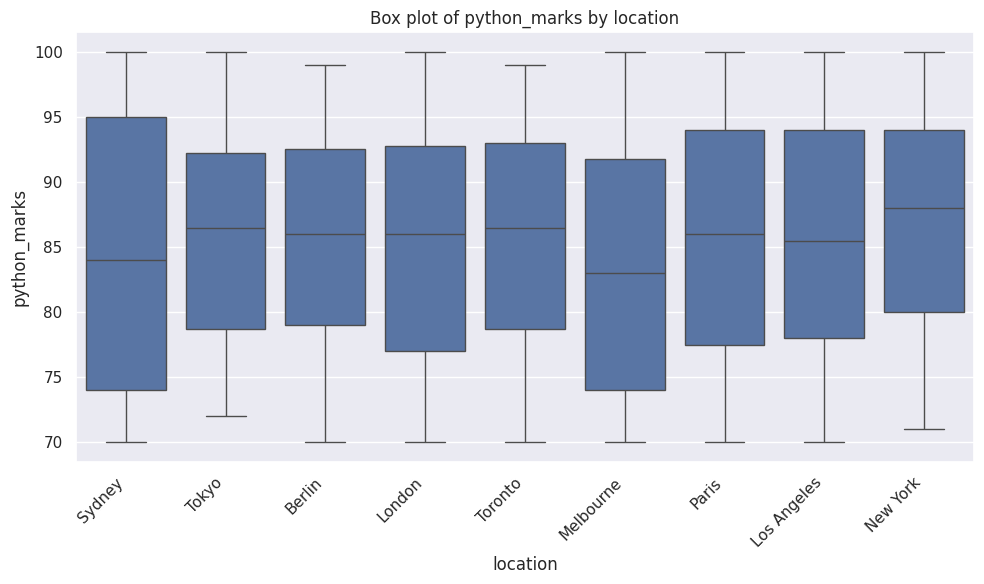

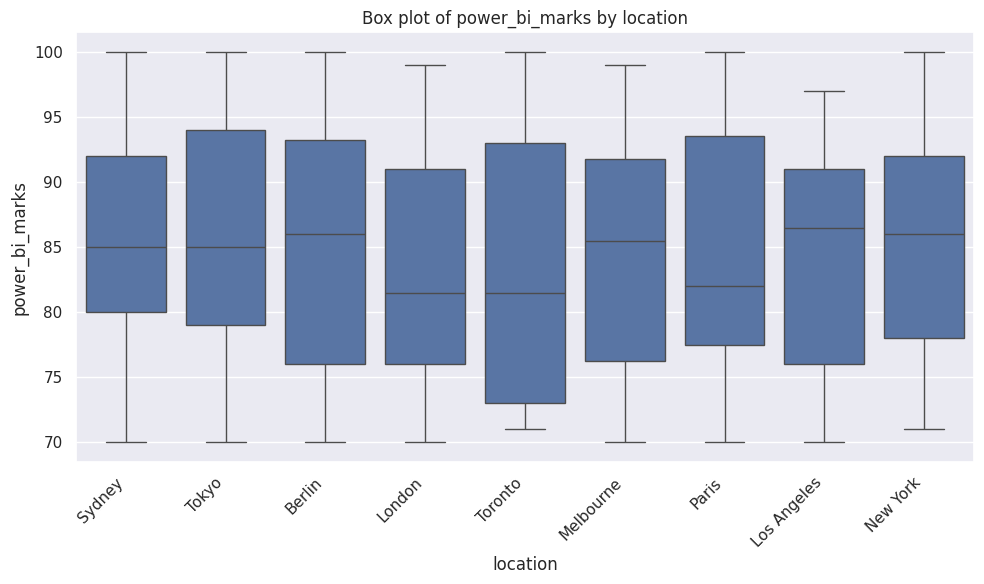

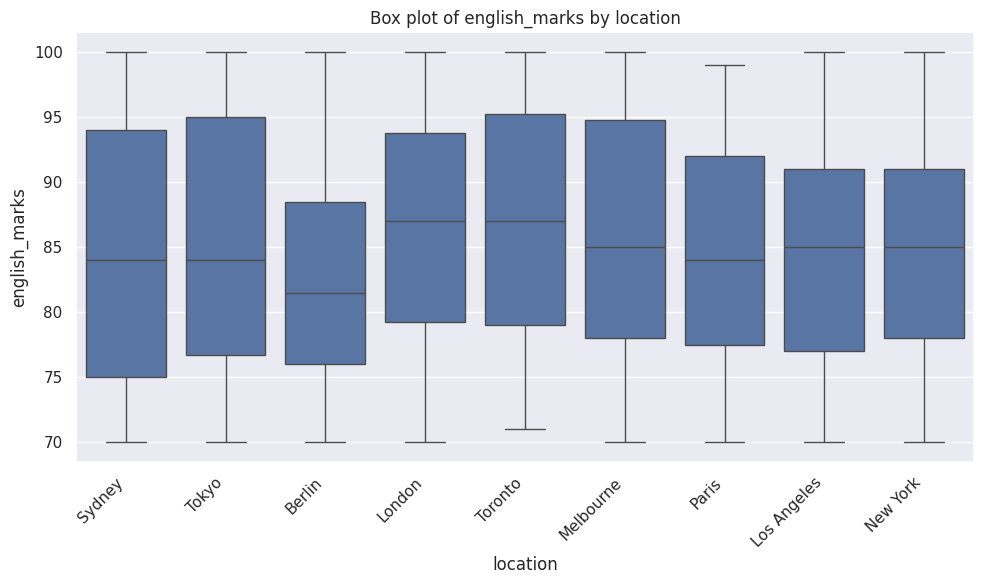

In [ ]:
# Numerical-Numerical relationships (Scatter plots)
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

# Iterate through pairs of numerical columns and create scatter plots
for i in range(len(numerical_cols)):
    for j in range(i + 1, len(numerical_cols)):
        col1 = numerical_cols[i]
        col2 = numerical_cols[j]
        plt.figure(figsize=(10, 6))
        sns.scatterplot(data=df, x=col1, y=col2)
        plt.title(f'Scatter plot of {col1} vs {col2}')
        plt.xlabel(col1)
        plt.ylabel(col2)
        plt.show()

# Categorical-Numerical relationships (Box plots)
categorical_cols = df.select_dtypes(include='object').columns.tolist()
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

# Iterate through categorical and numerical columns and create box plots
for cat_col in categorical_cols:
    for num_col in numerical_cols:
        plt.figure(figsize=(10, 6))
        sns.boxplot(data=df, x=cat_col, y=num_col)
        plt.title(f'Box plot of {num_col} by {cat_col}')
        plt.xlabel(cat_col)
        plt.ylabel(num_col)
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()
        plt.show()

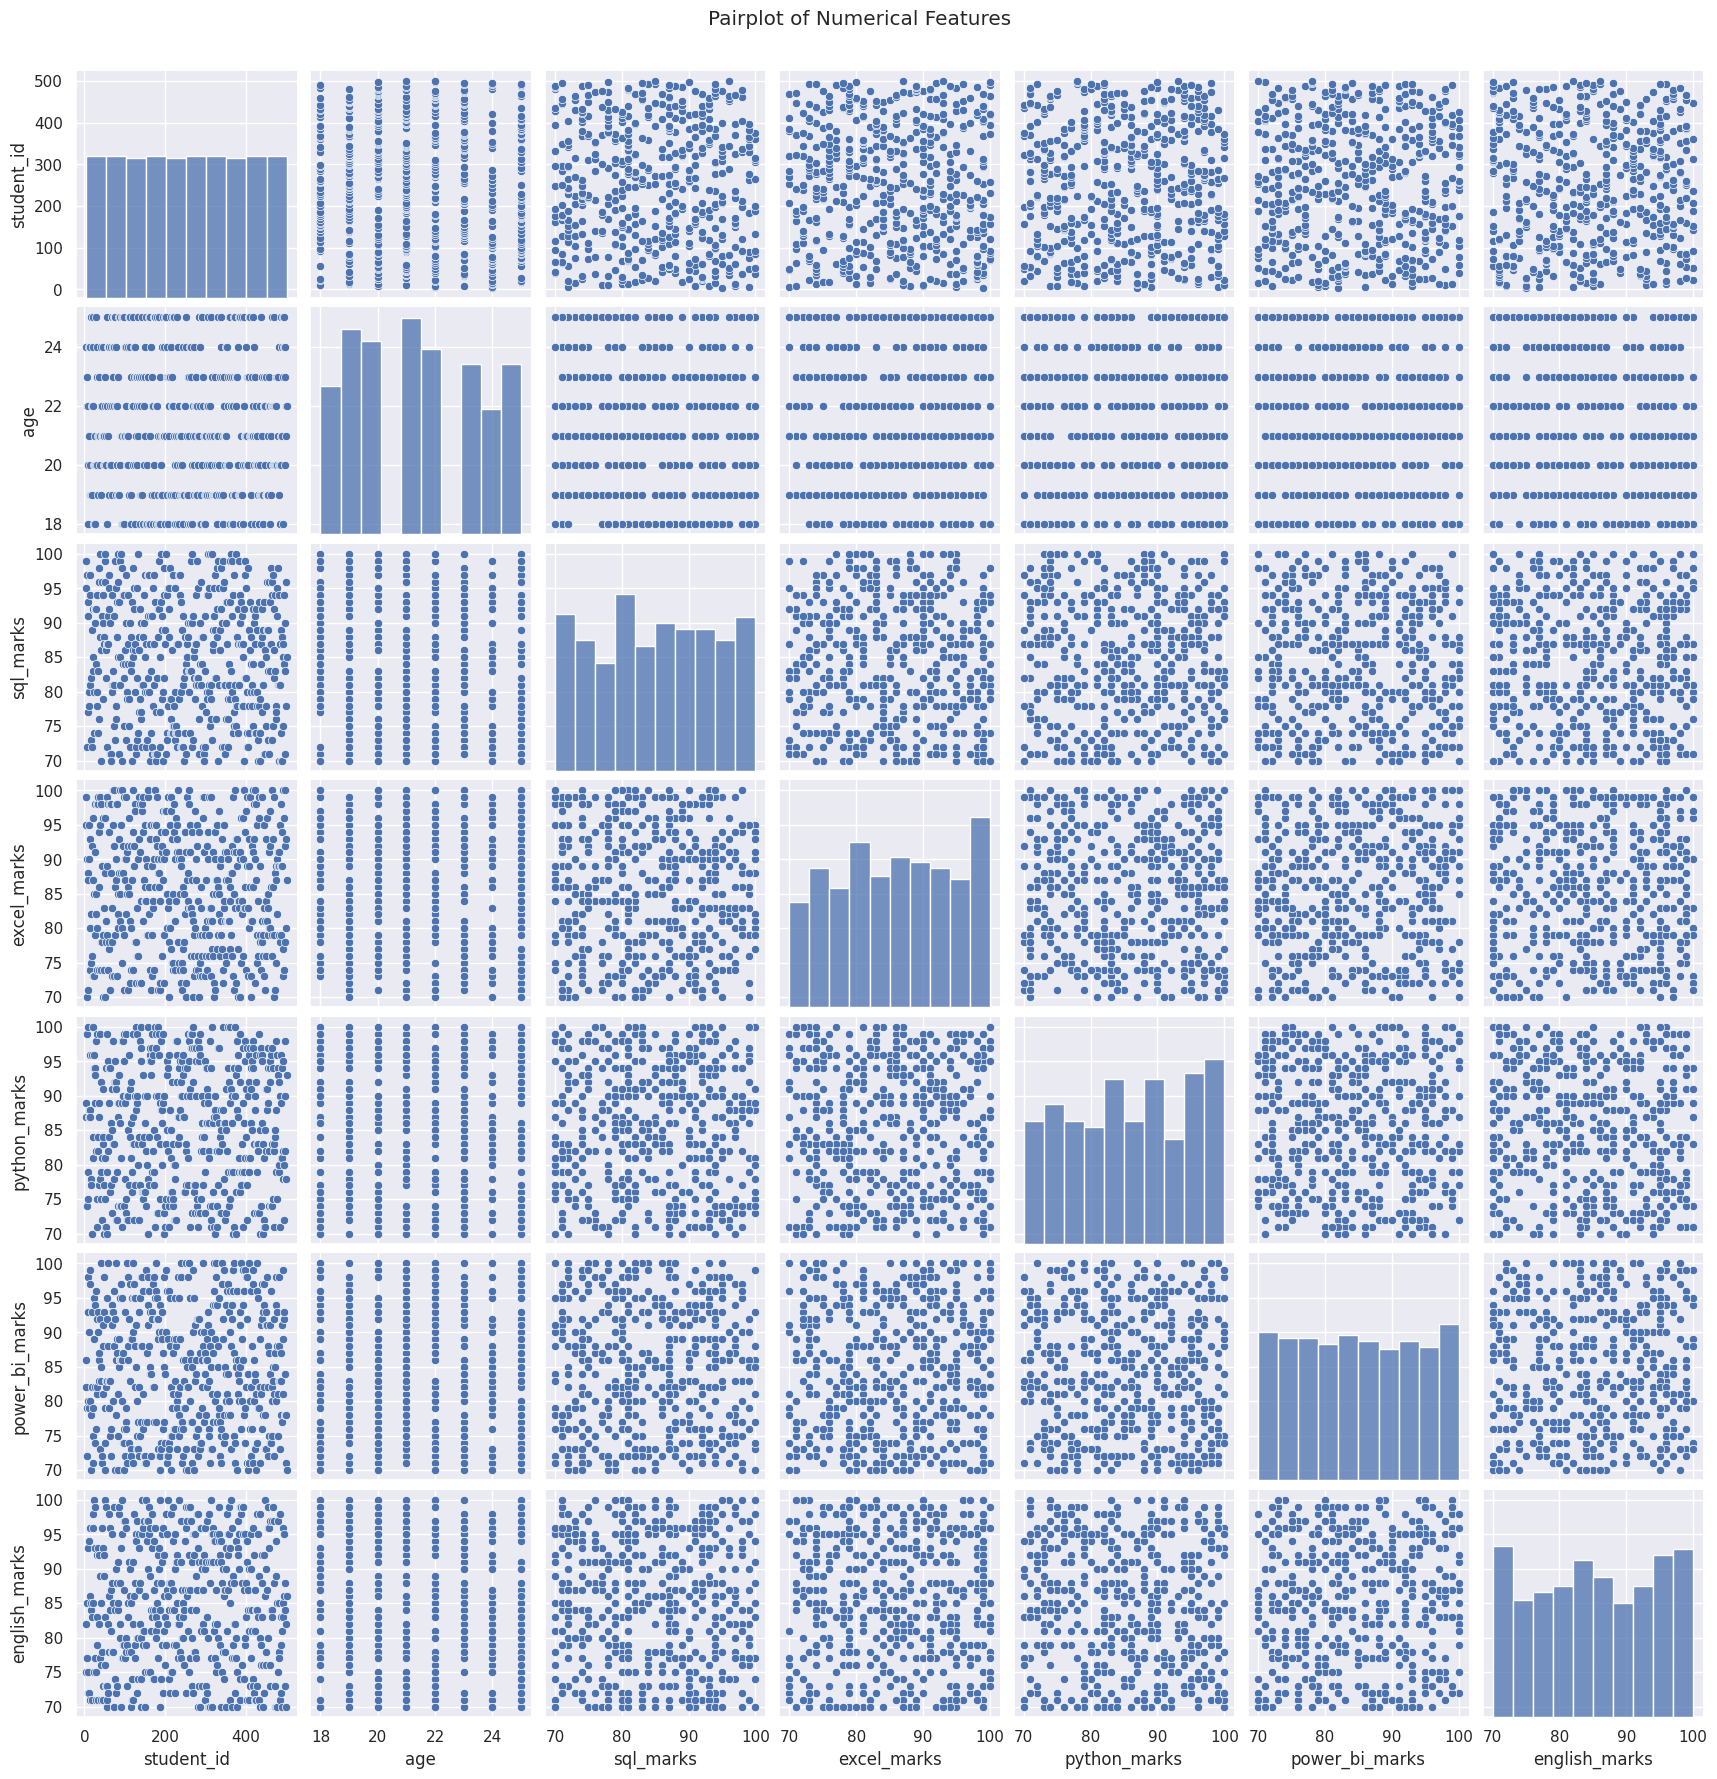

In [ ]:
sns.pairplot(df.select_dtypes(include=np.number))
plt.suptitle('Pairplot of Numerical Features', y=1.02)
plt.show()

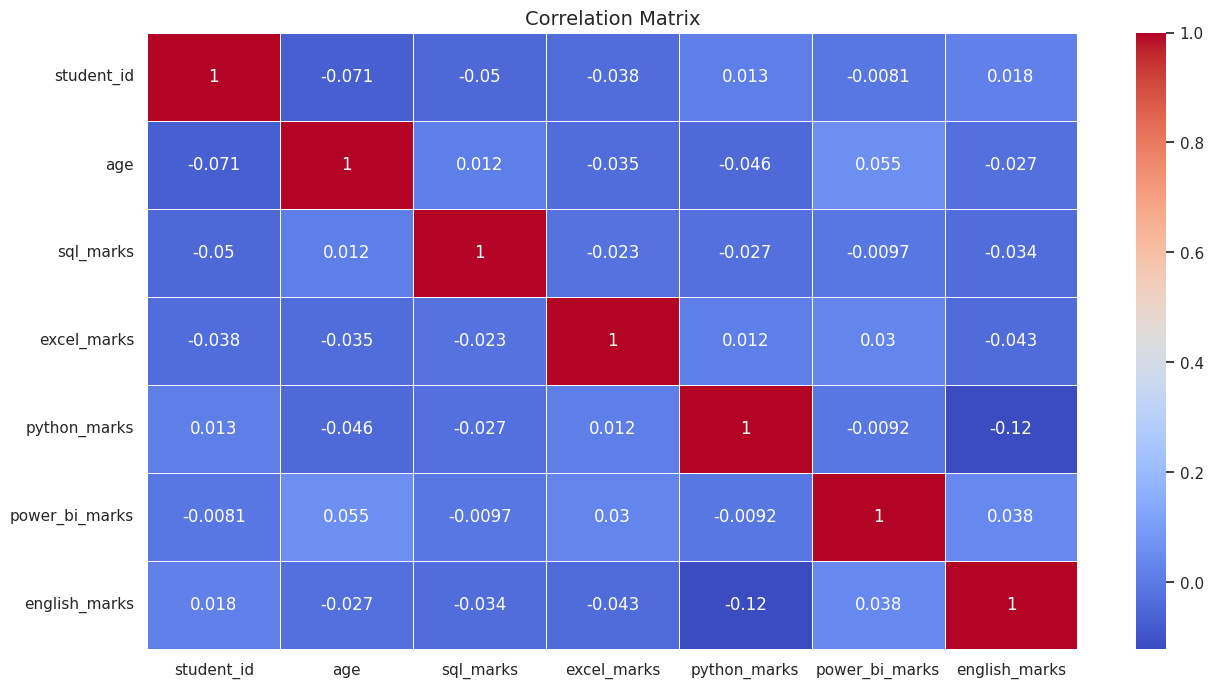

In [ ]:
plt.figure(figsize=(15, 8))
sns.heatmap(df.corr(numeric_only = True), annot=True, cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Matrix", fontsize=14)
plt.show()